# 📈 Polymarket BTC — XGBoost + Estrategia Production-Ready v8

## Cambios respecto a v7

### Nuevas features (16 total, +2)

- **`btc_poly_divergence`**: divergencia entre la dirección de BTC (`btc_return_since_open`)
  y el precio de Polymarket (`mkt_premium`). Cuando BTC sube pero el mercado no lo refleja,
  hay una oportunidad. Feature = `btc_return_since_open - mkt_premium`.
- **`recent_mkt_surprise_5`**: en los últimos 5 mercados resueltos, cuántas veces
  ganó el lado que el mercado infravaloraba (ask < 0.50). Un valor alto indica
  que el mercado ha estado equivocado recientemente → hay edge en ir contra el precio.

### Filtro más restrictivo

- **VALUE_EDGE subido de 0.04 a 0.08** — solo entrar cuando el modelo ve ≥8% más
  que el mercado. Reduce trades y concentra en las mejores oportunidades.

### Features (16)

| Grupo | Features | Fuente |
|---|---|---|
| BTC momentum | `ret_1m/3m/5m/10m`, `btc_return_since_open` | Feed BTC |
| BTC vol/volumen | `volatility_5m`, `vol_ratio`, `volume_1m` | Feed BTC |
| Polymarket book | `mkt_premium`, `up_book_imbalance`, `down_book_imbalance` | API Polymarket |
| Divergencia | `btc_poly_divergence` | BTC + Polymarket |
| Rachas | `recent_up_pct_5`, `recent_streak`, `recent_mkt_surprise_5` | Resoluciones históricas |
| Estado | `market_progress` | API Polymarket |

### Pipeline

```
Features (16) ──► XGBoost ──► IsotonicCalibration ──► p_final
                  (train)       (val)                   (test)
```

**Sin stop-loss por precio** — solo exit por Model-Flip.

---

## Garantías de ausencia de leakage

| Punto de decisión | Datos usados | Datos NO usados |
|---|---|---|
| Entrenamiento del modelo | Mercados train (más antiguos) | Val, test, `resolution` |
| Calibración isotónica | Predicciones en val | Test, `resolution` de test |
| `p_up` en snapshot T | Features de la fila T | Cualquier snapshot posterior a T |
| `btc_poly_divergence` en T | `btc_return_since_open[T]`, `mkt_premium[T]` — mismo snapshot ✓ |
| `recent_mkt_surprise_5` | Resoluciones + asks de mercados cerrados antes de T ✓ |
| Decisión de entrada en T | `p_up_T`, `ev_T`, `value_edge_T` | Snapshots posteriores a T |
| Decisión de exit en T' > T | `bid_T'`, `p_up_T'` calculados en T' | `resolution` final |


---
## 1 · Imports y Configuración

In [81]:
# =============================================================================
# 1. IMPORTS Y CONFIGURACIÓN
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, accuracy_score, brier_score_loss,
    classification_report, roc_curve,
)

# XGBoost (prioridad) / HistGBT (fallback) ------------------------------------
try:
    import xgboost as xgb
    USE_XGB = True
    print(f"XGBoost {xgb.__version__} disponible.")
except ImportError:
    USE_XGB = False
    print("XGBoost no instalado — usando HistGradientBoostingClassifier (sklearn).")
    print("  Para instalar: pip install xgboost")

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize': (13, 4.5),
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

# =============================================================================
# PARÁMETROS — ajusta aquí
# =============================================================================
CFG = dict(
    DATA_PATH    = '../dataset_with_resolution.csv',
    TRAIN_FRAC   = 0.60,
    VAL_FRAC     = 0.20,

    # Backtest
    STAKE        = 10.0,
    INIT_CAPITAL = 1_000.0,

    # ── Filtros de entrada ─────────────────────────────────────────────────
    ENTRY_LO     = 0.10,    # market_progress mínimo para entrar
    ENTRY_HI     = 0.40,    # market_progress máximo para entrar
    MIN_P        = 0.65,    # pérdidas concentradas en p<0.65 según backtest

    # ── Filtro clave: VALUE_EDGE ───────────────────────────────────────────
    # El modelo predice desde señales BTC + microestructura, no desde el precio del mercado.
    # Entrar cuando el modelo supera al mercado: value_edge = p_modelo - ask >= umbral.
    VALUE_EDGE   = 0.08,

    # ── Exit: solo Model-Flip ─────────────────────────────────────────────
    # Se sale cuando el modelo pierde convicción en la dirección elegida.
    FLIP_THRESH  = 0.20,
)

print("Configuración:")
for k, v in CFG.items():
    print(f"  {k:<14} = {v}")


XGBoost 3.2.0 disponible.
Configuración:
  DATA_PATH      = ../dataset_with_resolution.csv
  TRAIN_FRAC     = 0.6
  VAL_FRAC       = 0.2
  STAKE          = 10.0
  INIT_CAPITAL   = 1000.0
  ENTRY_LO       = 0.1
  ENTRY_HI       = 0.4
  MIN_P          = 0.65
  VALUE_EDGE     = 0.08
  FLIP_THRESH    = 0.2


---
## 2 · Carga y Limpieza

In [82]:
# =============================================================================
# 2. CARGA Y LIMPIEZA
# =============================================================================
df = pd.read_csv(CFG['DATA_PATH'], parse_dates=['timestamp'])

if df['timestamp'].dt.tz is None:
    df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')
else:
    df['timestamp'] = df['timestamp'].dt.tz_convert('UTC')

df = df.sort_values(['timestamp', 'market_slug']).reset_index(drop=True)

res_check = df.groupby('market_slug')['resolution'].nunique()
bad = res_check[res_check > 1].index
if len(bad):
    df = df[~df['market_slug'].isin(bad)]
    print(f"Eliminados {len(bad)} mercados con resolución inconsistente.")

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
# ⚠️ NO aplicar mediana global aquí — se haría leakage con datos de test.
# La imputación se realiza en Sección 4 usando TRAIN_MED (solo datos de entrenamiento).
df['market_progress'] = df['market_progress'].clip(0.0, 1.0)

print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Mercados: {df['market_slug'].nunique():,}")
print(f"Rango: {df['timestamp'].min()}  →  {df['timestamp'].max()}")
print(f"Resoluciones: {df['resolution'].value_counts().to_dict()}")

Dataset: 89,531 filas × 66 columnas
Mercados: 931
Rango: 2026-03-19 16:15:55.759706+00:00  →  2026-03-22 21:49:32.301299+00:00
Resoluciones: {'down': 45330, 'up': 44201}


In [83]:
# =============================================================================
# 2b. CÓMPUTO DE FEATURES DE TIMING (por mercado)
# =============================================================================
# Para cada snapshot calculamos:
#   seconds_from_open : segundos transcurridos desde el primer snapshot del mercado
#   seconds_to_close  : segundos restantes hasta el último snapshot (proxy del cierre)
#   market_duration_s : duración total estimada del mercado (en segundos)
#
# Nota: usamos primer/último snapshot como proxy del inicio/cierre real.
# En producción estos valores vendrán del campo market_end_date de la API.

_times = (
    df.groupby('market_slug')['timestamp']
    .agg(market_open='min', market_close='max')
    .reset_index()
)
df = df.merge(_times, on='market_slug', how='left')

df['market_duration_s'] = (
    df['market_close'] - df['market_open']
).dt.total_seconds().clip(lower=1)   # evita división por cero

df['seconds_from_open'] = (
    df['timestamp'] - df['market_open']
).dt.total_seconds().clip(lower=0)

df['seconds_to_close'] = (
    df['market_close'] - df['timestamp']
).dt.total_seconds().clip(lower=0)

print(f"Timing features añadidos. Duración media de mercado: "
      f"{df['market_duration_s'].mean():.1f} s  "
      f"(mediana: {df['market_duration_s'].median():.1f} s)")
print(df[['seconds_from_open','seconds_to_close','market_duration_s']].describe().round(1).to_string())


Timing features añadidos. Duración media de mercado: 296.7 s  (mediana: 296.8 s)
       seconds_from_open  seconds_to_close  market_duration_s
count            89531.0           89531.0            89531.0
mean               147.9             148.9              296.7
std                 86.3              86.3                2.3
min                  0.0               0.0              243.1
25%                 73.6              74.3              295.8
50%                147.7             149.0              296.8
75%                222.3             223.5              297.9
max                300.3             300.3              300.3


---
## 3 · Feature Engineering

**16 features, 2 fuentes de datos + resoluciones históricas.**

| Grupo | Features | Fuente |
|---|---|---|
| BTC momentum | `ret_1m/3m/5m/10m`, `btc_return_since_open` | Feed BTC |
| BTC vol/volumen | `volatility_5m`, `vol_ratio`, `volume_1m` | Feed BTC |
| Polymarket book | `mkt_premium`, `up_book_imbalance`, `down_book_imbalance` | API Polymarket |
| Divergencia | `btc_poly_divergence` | BTC + Polymarket |
| Rachas | `recent_up_pct_5`, `recent_streak`, `recent_mkt_surprise_5` | Resoluciones históricas |
| Estado | `market_progress` | API Polymarket |

### Features nuevas en v8

**`btc_poly_divergence`** = `btc_return_since_open − mkt_premium`
- Mide el desacuerdo entre lo que BTC está haciendo y lo que Polymarket pricea.
- Valor alto → BTC sube pero el mercado no lo refleja (oportunidad alcista).
- Valor bajo → BTC baja pero el mercado sigue alto (oportunidad bajista).
- Calculado en el mismo snapshot T, sin look-ahead ✓

**`recent_mkt_surprise_5`** = fracción de "sorpresas" en los últimos 5 mercados
- Una "sorpresa" es cuando gana el lado que el mercado infravaloraba (ask < 0.50).
- Valor alto → el mercado ha estado equivocado recientemente.
- Solo usa resoluciones de mercados cerrados antes de T ✓

### Auditoría look-ahead

- `btc_poly_divergence` = datos del snapshot actual ✓
- `recent_mkt_surprise_5` = resoluciones + último ask de mercados ya cerrados ✓
- `vol_ratio`, `mkt_premium`, `up_book_imbalance` = mismo snapshot ✓
- `recent_up_pct_5`, `recent_streak` = mercados cerrados antes de T ✓


In [84]:
# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================
fe = df.copy()

# ── BTC: régimen de volatilidad ───────────────────────────────────────────────
fe['vol_ratio'] = fe['volatility_3m'] / (fe['volatility_5m'] + 1e-9)

# ── Polymarket: sesgo direccional del mercado ─────────────────────────────────
fe['mkt_premium'] = fe['up_ask_p_1'] - fe['down_ask_p_1']

# ── Polymarket: presión de libro de órdenes L1 ───────────────────────────────
fe['up_book_imbalance'] = (
    (fe['up_bid_s_1'] - fe['up_ask_s_1']) /
    (fe['up_bid_s_1'] + fe['up_ask_s_1'] + 1e-9)
)
fe['down_book_imbalance'] = (
    (fe['down_bid_s_1'] - fe['down_ask_s_1']) /
    (fe['down_bid_s_1'] + fe['down_ask_s_1'] + 1e-9)
)

# ── Divergencia BTC vs Polymarket ─────────────────────────────────────────────
# BTC sube (btc_return_since_open > 0) pero Polymarket no lo refleja
# (mkt_premium bajo) → oportunidad. Todo del mismo snapshot T.
fe['btc_poly_divergence'] = fe['btc_return_since_open'] - fe['mkt_premium']

# ── Rachas de resoluciones recientes (sin look-ahead) ────────────────────────
STREAK_WINDOW = 5

# Tabla de resoluciones por mercado, ordenada por cierre
_res = (
    fe.groupby('market_slug').agg(
        resolution=('resolution', 'first'),
        close_ts=('market_close', 'first'),
        last_up_ask=('up_ask_p_1', 'last'),   # último ask UP antes de resolución
    )
    .sort_values('close_ts')
    .reset_index()
)
_res['res_up'] = (_res['resolution'].str.lower() == 'up').astype(int)

# % UP en los últimos N mercados (excluyendo el actual)
_res['recent_up_pct_5'] = (
    _res['res_up']
    .shift(1)
    .rolling(STREAK_WINDOW, min_periods=1)
    .mean()
)

# Racha consecutiva: positiva si UP, negativa si DOWN
def compute_streak(series):
    shifted = series.shift(1)
    streaks = []
    for i in range(len(shifted)):
        if pd.isna(shifted.iloc[i]):
            streaks.append(0)
            continue
        streak = 0
        last_val = shifted.iloc[i]
        for j in range(i, -1, -1):
            if pd.isna(shifted.iloc[j]) or shifted.iloc[j] != last_val:
                break
            streak += 1
        streaks.append(streak if last_val == 1 else -streak)
    return streaks

_res['recent_streak'] = compute_streak(_res['res_up'])

# ── Racha ponderada: "sorpresas" del mercado ──────────────────────────────────
# Una "sorpresa" = ganó el lado que el mercado infravaloraba (ask < 0.50).
# Si UP ganó y up_ask < 0.50 → el mercado no lo esperaba → sorpresa.
# Si DOWN ganó y up_ask >= 0.50 (= down_ask < 0.50) → sorpresa.
_res['was_surprise'] = (
    ((_res['res_up'] == 1) & (_res['last_up_ask'] < 0.50)) |
    ((_res['res_up'] == 0) & (_res['last_up_ask'] >= 0.50))
).astype(int)

_res['recent_mkt_surprise_5'] = (
    _res['was_surprise']
    .shift(1)
    .rolling(STREAK_WINDOW, min_periods=1)
    .mean()
)

# Mapear al dataframe principal via market_slug
_streak_map = _res.set_index('market_slug')[[
    'recent_up_pct_5', 'recent_streak', 'recent_mkt_surprise_5'
]]
fe = fe.merge(_streak_map, left_on='market_slug', right_index=True, how='left')
fe['recent_up_pct_5']       = fe['recent_up_pct_5'].fillna(0.5)
fe['recent_streak']         = fe['recent_streak'].fillna(0)
fe['recent_mkt_surprise_5'] = fe['recent_mkt_surprise_5'].fillna(0.5)

print(f"Rachas calculadas (ventana={STREAK_WINDOW}):")
print(f"  recent_up_pct_5:       mean={fe['recent_up_pct_5'].mean():.3f}  std={fe['recent_up_pct_5'].std():.3f}")
print(f"  recent_streak:         mean={fe['recent_streak'].mean():.2f}   rango=[{fe['recent_streak'].min():.0f}, {fe['recent_streak'].max():.0f}]")
print(f"  recent_mkt_surprise_5: mean={fe['recent_mkt_surprise_5'].mean():.3f}  std={fe['recent_mkt_surprise_5'].std():.3f}")
print(f"  btc_poly_divergence:   mean={fe['btc_poly_divergence'].mean():.4f}  std={fe['btc_poly_divergence'].std():.4f}")

# ── Target ───────────────────────────────────────────────────────────────────
fe['y'] = (fe['resolution'].str.lower() == 'up').astype(int)

# ── Feature set v8 (16 features) ─────────────────────────────────────────────
FEATURES = [
    # BTC momentum (multi-timeframe)
    'ret_1m', 'ret_3m', 'ret_5m', 'ret_10m',
    'btc_return_since_open',
    # BTC volatilidad y volumen
    'volatility_5m', 'vol_ratio', 'volume_1m',
    # Polymarket book
    'mkt_premium',
    'up_book_imbalance', 'down_book_imbalance',
    # Divergencia
    'btc_poly_divergence',
    # Rachas de resoluciones recientes
    'recent_up_pct_5', 'recent_streak', 'recent_mkt_surprise_5',
    # Estado
    'market_progress',
]
FEATURES = [f for f in FEATURES if f in fe.columns]
print(f"\nFeatures v8: {len(FEATURES)}")
missing = [f for f in [
    'ret_1m','ret_3m','ret_5m','ret_10m','btc_return_since_open',
    'volatility_5m','vol_ratio','volume_1m','mkt_premium',
    'up_book_imbalance','down_book_imbalance','btc_poly_divergence',
    'recent_up_pct_5','recent_streak','recent_mkt_surprise_5','market_progress',
] if f not in fe.columns]
if missing:
    print(f"  ⚠️  Columnas no encontradas: {missing}")
else:
    print("  ✓ Todas las columnas presentes")
print(fe[FEATURES].describe().round(3).to_string())


Rachas calculadas (ventana=5):
  recent_up_pct_5:       mean=0.497  std=0.214
  recent_streak:         mean=-0.04   rango=[-8, 8]
  recent_mkt_surprise_5: mean=0.037  std=0.116
  btc_poly_divergence:   mean=-0.0032  std=0.5204

Features v8: 16
  ✓ Todas las columnas presentes
          ret_1m     ret_3m     ret_5m    ret_10m  btc_return_since_open  volatility_5m  vol_ratio  volume_1m  mkt_premium  up_book_imbalance  down_book_imbalance  btc_poly_divergence  recent_up_pct_5  recent_streak  recent_mkt_surprise_5  market_progress
count  89531.000  89531.000  89531.000  89531.000              89531.000      89530.000  89530.000  89530.000    83241.000          83240.000            83237.000            83241.000        89531.000      89531.000              89531.000        89531.000
mean       0.001     -0.000     -0.000     -0.000                 -0.000          0.000      0.935     10.720        0.003             -0.006                0.006               -0.003            0.497         -0

---
## 4 · Split Temporal y Matrices

In [85]:
# =============================================================================
# 4. SPLIT TEMPORAL POR MERCADO
# =============================================================================
market_order = (
    fe.groupby('market_slug')['timestamp'].min()
      .sort_values().index.tolist()
)
N = len(market_order)
n_train = int(N * CFG['TRAIN_FRAC'])
n_val   = int(N * CFG['VAL_FRAC'])

train_m = market_order[:n_train]
val_m   = market_order[n_train : n_train + n_val]
test_m  = market_order[n_train + n_val :]

tr = fe[fe['market_slug'].isin(train_m)].copy()
va = fe[fe['market_slug'].isin(val_m)].copy()
te = fe[fe['market_slug'].isin(test_m)].copy()

assert tr['timestamp'].max() < va['timestamp'].min(), "LEAKAGE train/val"
assert va['timestamp'].max() < te['timestamp'].min(), "LEAKAGE val/test"
print("Sin leakage temporal confirmado.")

TRAIN_MED = pd.DataFrame(tr[FEATURES].values, columns=FEATURES).median()

def to_matrix(df_split):
    return (
        pd.DataFrame(df_split[FEATURES].values, columns=FEATURES)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(TRAIN_MED)
        .values
    )

X_tr = to_matrix(tr); y_tr = tr['y'].values
X_va = to_matrix(va); y_va = va['y'].values
X_te = to_matrix(te); y_te = te['y'].values

print(f"\n{'Split':<12} {'Mercados':>9} {'Filas':>8} {'UP%':>6}")
print("-" * 38)
for name, split, y in [('Train', tr, y_tr), ('Validación', va, y_va), ('Test', te, y_te)]:
    print(f"{name:<12} {split['market_slug'].nunique():>9,} {len(split):>8,} {y.mean():>6.1%}")

Sin leakage temporal confirmado.

Split         Mercados    Filas    UP%
--------------------------------------
Train              558   53,586  50.3%
Validación         186   17,954  48.7%
Test               187   17,991  47.3%


---
## 5 · Entrenamiento XGBoost

XGBoost con early stopping en validación + calibración isotónica.


Mejor iteración: 24


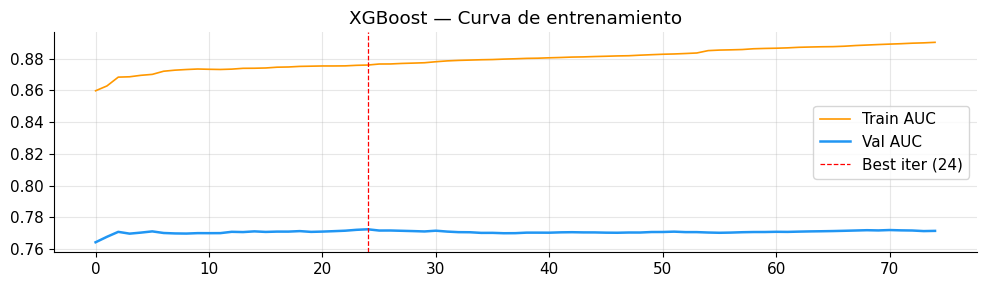


Set              AUC   Accuracy    Brier
----------------------------------------
Validación    0.7749     0.6898   0.1889
Test          0.8432     0.7598   0.1676

Classification report (test):
              precision    recall  f1-score   support

        DOWN       0.81      0.71      0.76      9473
          UP       0.72      0.81      0.76      8518

    accuracy                           0.76     17991
   macro avg       0.76      0.76      0.76     17991
weighted avg       0.77      0.76      0.76     17991



In [86]:
# =============================================================================
# 5. ENTRENAMIENTO — XGBoost
# =============================================================================
if USE_XGB:
    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=FEATURES)
    dval   = xgb.DMatrix(X_va, label=y_va, feature_names=FEATURES)

    xgb_params = {
        'objective'        : 'binary:logistic',
        'eval_metric'      : 'auc',
        'eta'              : 0.03,
        'max_depth'        : 5,
        'min_child_weight' : 20,
        'subsample'        : 0.80,
        'colsample_bytree' : 0.80,
        'alpha'            : 0.1,
        'lambda'           : 1.0,
        'seed'             : SEED,
    }

    evals_result = {}
    booster = xgb.train(
        xgb_params, dtrain,
        num_boost_round       = 800,
        evals                 = [(dtrain, 'train'), (dval, 'val')],
        early_stopping_rounds = 50,
        evals_result          = evals_result,
        verbose_eval          = False,
    )
    print(f"Mejor iteración: {booster.best_iteration}")

    class XGBModel:
        def __init__(self, bst):
            self.bst = bst
        def predict_proba(self, X):
            dm = xgb.DMatrix(X, feature_names=FEATURES)
            p  = self.bst.predict(dm)
            return np.column_stack([1 - p, p])
        @property
        def feature_importances_(self):
            scores = self.bst.get_score(importance_type='gain')
            return np.array([scores.get(f, 0.0) for f in FEATURES])

    raw_model = XGBModel(booster)

    # Curva de entrenamiento
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(evals_result['train']['auc'], lw=1.2, label='Train AUC', color='#FF9800')
    ax.plot(evals_result['val']['auc'],   lw=1.8, label='Val AUC',   color='#2196F3')
    ax.axvline(booster.best_iteration, ls='--', color='red', lw=0.9,
               label=f'Best iter ({booster.best_iteration})')
    ax.set_title('XGBoost — Curva de entrenamiento'); ax.legend()
    plt.tight_layout(); plt.show()

else:
    raw_model = HistGradientBoostingClassifier(
        max_iter=600, learning_rate=0.03, max_depth=5,
        min_samples_leaf=20, l2_regularization=0.1, random_state=SEED,
    )
    raw_model.fit(X_tr, y_tr)
    print("HistGradientBoostingClassifier entrenado (fallback).")

# Calibración isotónica — solo sobre validación
p_va_raw = raw_model.predict_proba(X_va)[:, 1]
iso_cal  = IsotonicRegression(out_of_bounds='clip')
iso_cal.fit(p_va_raw, y_va)

class CalibratedModel:
    def __init__(self, base, cal):
        self.base = base; self.cal = cal
    def predict_proba(self, X):
        p_raw = self.base.predict_proba(X)[:, 1]
        p_cal = self.cal.transform(p_raw)
        return np.column_stack([1 - p_cal, p_cal])

MODEL = CalibratedModel(raw_model, iso_cal)

p_va = MODEL.predict_proba(X_va)[:, 1]
p_te = MODEL.predict_proba(X_te)[:, 1]

print(f"\n{'Set':<12} {'AUC':>7} {'Accuracy':>10} {'Brier':>8}")
print("-" * 40)
for name, p, y in [('Validación', p_va, y_va), ('Test', p_te, y_te)]:
    auc = roc_auc_score(y, p)
    acc = accuracy_score(y, (p >= 0.5).astype(int))
    bs  = brier_score_loss(y, p)
    print(f"{name:<12} {auc:>7.4f} {acc:>10.4f} {bs:>8.4f}")

print("\nClassification report (test):")
print(classification_report(y_te, (p_te >= 0.5).astype(int), target_names=['DOWN','UP']))


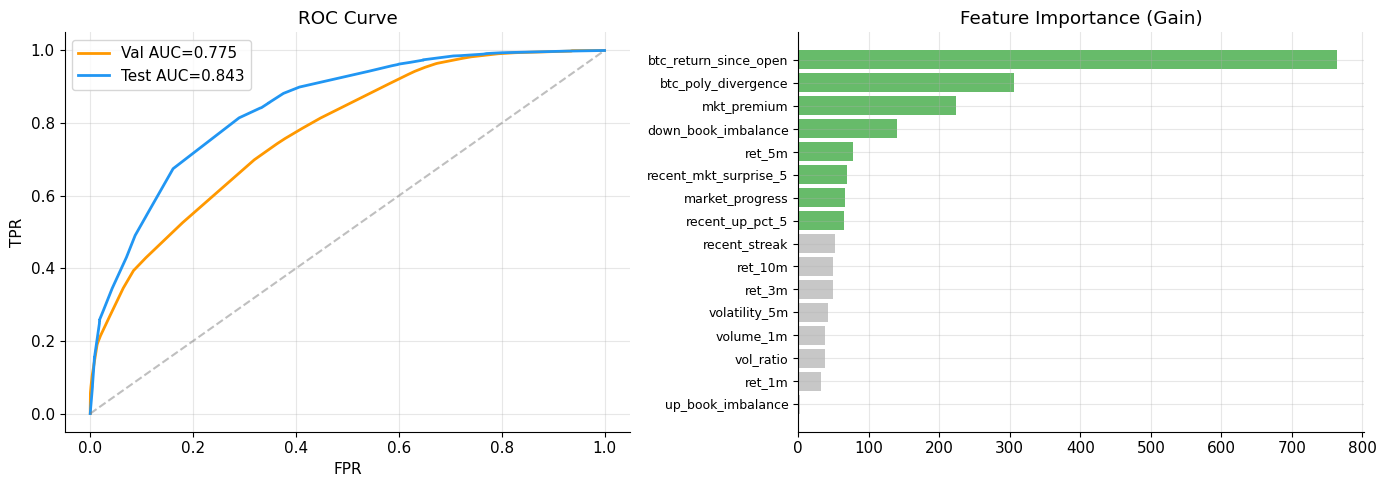

In [87]:
# ROC y Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for (name, p, y), c in zip(
    [('Val', p_va, y_va), ('Test', p_te, y_te)],
    ['#FF9800', '#2196F3']
):
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, color=c, lw=2, label=f"{name} AUC={roc_auc_score(y,p):.3f}")
axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[0].set(title='ROC Curve', xlabel='FPR', ylabel='TPR')
axes[0].legend()

# Feature importance
if hasattr(raw_model, 'feature_importances_'):
    fi = pd.Series(raw_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    colors_fi = ['#4CAF50' if v >= fi.median() else '#BDBDBD' for v in fi.values]
    axes[1].barh(range(len(fi)), fi.values, color=colors_fi, alpha=0.85)
    axes[1].set_yticks(range(len(fi)))
    axes[1].set_yticklabels(fi.index, fontsize=9)
    axes[1].set_title('Feature Importance (Gain)')

plt.tight_layout()
plt.show()


---
## 5b · Exportar modelo para producción

Guarda los artefactos necesarios para el script `signal_engine.py`:
- `model/booster.json` — XGBoost serializado
- `model/isotonic.pkl` — calibración isotónica
- `model/config.json` — FEATURES, TRAIN_MED, CFG


In [88]:
# =============================================================================
# 5b. EXPORTAR ARTEFACTOS PARA PRODUCCIÓN
# =============================================================================
import os, pickle, json as _json

MODEL_DIR = 'model'
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. XGBoost booster
if USE_XGB:
    booster.save_model(os.path.join(MODEL_DIR, 'booster.json'))
    print(f"  ✓ booster.json guardado ({booster.best_iteration} árboles)")
else:
    with open(os.path.join(MODEL_DIR, 'histgbt.pkl'), 'wb') as f:
        pickle.dump(raw_model, f)
    print("  ✓ histgbt.pkl guardado (fallback)")

# 2. Calibración isotónica
with open(os.path.join(MODEL_DIR, 'isotonic.pkl'), 'wb') as f:
    pickle.dump(iso_cal, f)
print("  ✓ isotonic.pkl guardado")

# 3. Config: features, medianas de imputación, parámetros de estrategia
config = {
    'FEATURES': FEATURES,
    'TRAIN_MED': {k: float(v) for k, v in TRAIN_MED.items()},
    'CFG': {k: v for k, v in CFG.items() if k != 'DATA_PATH'},
    'USE_XGB': USE_XGB,
}
with open(os.path.join(MODEL_DIR, 'config.json'), 'w') as f:
    _json.dump(config, f, indent=2)
print("  ✓ config.json guardado")

print(f"\nArtefactos en ./{MODEL_DIR}/")
for fn in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(os.path.join(MODEL_DIR, fn))
    print(f"  {fn:<20} {size/1024:.1f} KB")


  ✓ booster.json guardado (24 árboles)
  ✓ isotonic.pkl guardado
  ✓ config.json guardado

Artefactos en ./model/
  booster.json         278.2 KB
  config.json          1.2 KB
  isotonic.pkl         1.0 KB


---
## 6 · Scoring, EV y VALUE_EDGE

Distribución del VALUE_EDGE (test set):
       value_edge_up  value_edge_down
count     17355.0000       17142.0000
mean         -0.0108           0.0074
std           0.0755           0.0781
min          -0.3968          -0.3725
25%          -0.0586          -0.0338
50%          -0.0100           0.0039
75%           0.0275           0.0532
max           0.5314           0.5027


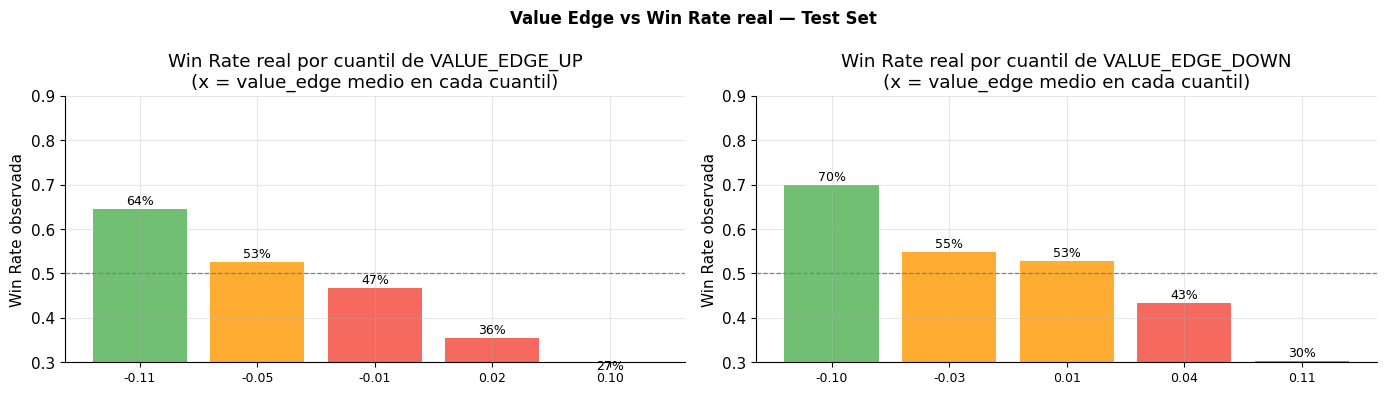

In [89]:
# =============================================================================
# 6. SCORING, EV Y VALUE_EDGE
# =============================================================================
# Sin leakage: predict_proba se aplica por fila usando únicamente las features
# de ese snapshot. Cada fila es independiente del resto en la inferencia.

X_all    = to_matrix(fe)
fe['p_up']   = MODEL.predict_proba(X_all)[:, 1]
fe['p_down'] = 1.0 - fe['p_up']

# EV = P(ganar) × win_net + P(perder) × loss_net
fe['ev_up']   = fe['p_up']   * fe['up_win_net']   + fe['p_down'] * fe['up_loss_net']
fe['ev_down'] = fe['p_down'] * fe['down_win_net'] + fe['p_up']   * fe['down_loss_net']

# VALUE_EDGE = P(modelo) − precio_ask_mercado
# Mide cuánto más confiado está el modelo que el mercado.
# Solo tiene sentido entrar cuando el modelo ve algo que el mercado no ha descontado.
fe['value_edge_up']   = fe['p_up']   - fe['up_ask_p_1']
fe['value_edge_down'] = fe['p_down'] - fe['down_ask_p_1']

test_fe = fe[fe['market_slug'].isin(test_m)].copy()

# Análisis del value_edge en el test set
print("Distribución del VALUE_EDGE (test set):")
print(test_fe[['value_edge_up','value_edge_down']].describe().round(4).to_string())

# Visualización: WR observada por cuartil de value_edge
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in [
    (axes[0], 'value_edge_up',   'VALUE_EDGE_UP'),
    (axes[1], 'value_edge_down', 'VALUE_EDGE_DOWN'),
]:
    test_fe['_q'] = pd.qcut(test_fe[col], q=5, labels=False, duplicates='drop')
    grp = test_fe.groupby('_q', observed=True)
    means = grp['y'].mean() if col == 'value_edge_up' else 1 - grp['y'].mean()
    edges = grp[col].mean()
    bars = ax.bar(range(len(means)), means.values, alpha=0.8,
                  color=['#4CAF50' if v > 0.55 else '#FF9800' if v > 0.50 else '#F44336'
                         for v in means.values])
    ax.axhline(0.5, ls='--', color='gray', lw=0.9)
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels([f'{v:.2f}' for v in edges.values], fontsize=9)
    ax.set_title(f'Win Rate real por cuantil de {title}\n(x = value_edge medio en cada cuantil)')
    ax.set_ylabel('Win Rate observada'); ax.set_ylim(0.3, 0.9)
    for bar, v in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.0%}', ha='center', fontsize=9)

plt.suptitle('Value Edge vs Win Rate real — Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 7 · Estrategia de Entrada (Production-Ready)

### Reglas de entrada — 2 filtros

El modelo predice desde señales BTC + microestructura (sin `up_ask_p_1`).
Entrar cuando el modelo supera al mercado y tiene convicción mínima.

```
value_edge = p_modelo - ask_mercado

Condición de entrada (dirección UP):
  market_progress  ∈ [ENTRY_LO, ENTRY_HI]  →  ventana temporal
  p_up             >= MIN_P                  →  convicción mínima del modelo
  value_edge       >= VALUE_EDGE             →  modelo supera al mercado
```

En producción:
```python
value_edge = p_model - market_ask
if p_model >= MIN_P and value_edge >= VALUE_EDGE:
    enter(direction)
```



In [90]:
# =============================================================================
# 7. ESTRATEGIA DE ENTRADA — PRODUCCIÓN-CORRECTA
# =============================================================================

def find_entry(market_snaps, cfg):
    """
    Encuentra el punto de entrada para UN mercado.
    Procesamiento en orden de timestamp: solo usa datos del snapshot actual.
    2 filtros: MIN_P + VALUE_EDGE.
    """
    lo, hi = cfg['ENTRY_LO'], cfg['ENTRY_HI']

    window = (
        market_snaps[
            (market_snaps['market_progress'] >= lo) &
            (market_snaps['market_progress'] <= hi)
        ]
        .sort_values('timestamp')
        .reset_index(drop=True)
    )

    if window.empty:
        return None, None

    for _, row in window.iterrows():
        candidates = []
        for direction, p_col, ask_col in [
            ('UP',   'p_up',   'up_ask_p_1'),
            ('DOWN', 'p_down', 'down_ask_p_1'),
        ]:
            ve = float(row[p_col]) - float(row[ask_col])
            if (
                float(row[p_col]) >= cfg['MIN_P'] and
                ve                >= cfg['VALUE_EDGE']
            ):
                candidates.append((direction, ve))

        if candidates:
            best_dir = max(candidates, key=lambda x: x[1])[0]
            return row, best_dir

    return None, None


# Sanity check: orden cronológico en todos los mercados del test set
for mkt, grp in test_fe.groupby('market_slug'):
    ts = grp.sort_values('timestamp')['timestamp'].values
    assert np.all(ts[:-1] <= ts[1:]), f"Timestamps no monotónicos en {mkt}"
print("Orden cronológico verificado en todos los mercados del test set.")

# Distribución de entradas
entry_stats = []
for mkt, grp in test_fe.groupby('market_slug'):
    snaps = grp.sort_values('timestamp').reset_index(drop=True)
    row, direction = find_entry(snaps, CFG)
    if row is not None:
        p_col  = f'p_{direction.lower()}'
        ask_col = 'up_ask_p_1' if direction == 'UP' else 'down_ask_p_1'
        entry_stats.append({
            'market'     : mkt,
            'direction'  : direction,
            'timestamp'  : row['timestamp'],
            'progress'   : row['market_progress'],
            'p'          : row[p_col],
            'value_edge' : float(row[p_col]) - float(row[ask_col]),
            'ask'        : row[ask_col],
        })

df_entries = pd.DataFrame(entry_stats)
print(f"\nMercados con señal: {len(df_entries)} / {test_fe['market_slug'].nunique()}")
if not df_entries.empty:
    print(f"Dirección: {df_entries['direction'].value_counts().to_dict()}")
    print(f"\nDistribución de entradas:")
    print(df_entries[['direction','progress','p','value_edge','ask']].describe().round(3).to_string())


Orden cronológico verificado en todos los mercados del test set.

Mercados con señal: 15 / 187
Dirección: {'DOWN': 8, 'UP': 7}

Distribución de entradas:
       progress       p  value_edge     ask
count    15.000  15.000      15.000  15.000
mean      0.260   0.862       0.110   0.751
std       0.111   0.099       0.022   0.109
min       0.107   0.653       0.082   0.550
25%       0.148   0.790       0.091   0.670
50%       0.250   0.894       0.103   0.760
75%       0.380   0.928       0.127   0.835
max       0.397   0.992       0.150   0.910


---
## 8 · Motor de Backtest con Exit

**Una única regla de exit: Model-Flip.**

El stop-loss por precio se elimina porque en mercados binarios de Polymarket:
- El precio de la share NO converge suavemente — oscila hasta resolución
- Un SL del 15% sobre el bid dispara el 75% de las veces, cortando ganadores
- La señal real de que la tesis cambió es el modelo, no el precio

Cuando `P(dirección)_t < FLIP_THRESH`, el modelo ha visto nuevos datos (BTC, order book)
que contradicen la tesis original → es el momento de salir.

In [91]:
# =============================================================================
# 8. MOTOR DE BACKTEST
# =============================================================================

def early_exit_pnl(stake, entry_ask, exit_bid):
    """PnL de salida anticipada: stake × (exit_bid / entry_ask − 1)."""
    return stake * (exit_bid / entry_ask - 1.0)


def run_backtest(snapshot_df, cfg):
    """
    Backtest producción-correcto. Un trade por mercado.

    Garantías:
    - Entrada: find_entry procesa en orden de timestamp, entra en el primero
      que cumple criterios (sin look-ahead).
    - Exit: solo evalúa snapshots con timestamp > entry_timestamp.
    - 'resolution' se usa solo en pnl_at_resolution (referencia post-hoc).
    """
    FLIP  = cfg['FLIP_THRESH']
    STAKE = cfg['STAKE']
    trades = []

    for mkt, grp in snapshot_df.groupby('market_slug'):
        snaps = grp.sort_values('timestamp').reset_index(drop=True)

        # 1. Encontrar entrada
        entry_row, direction = find_entry(snaps, cfg)
        if entry_row is None:
            continue

        entry_ts  = entry_row['timestamp']
        entry_ask = (
            entry_row['up_ask_p_1']   if direction == 'UP'
            else entry_row['down_ask_p_1']
        )
        if entry_ask <= 0 or np.isnan(entry_ask):
            continue

        # Referencia: resultado en resolución (solo estadística comparativa)
        resolution = snaps['resolution'].iloc[0]
        actual_up  = (resolution.lower() == 'up')
        won_at_res = (actual_up if direction == 'UP' else not actual_up)
        win_net    = entry_row['up_win_net']  if direction == 'UP' else entry_row['down_win_net']
        loss_net   = entry_row['up_loss_net'] if direction == 'UP' else entry_row['down_loss_net']
        pnl_at_res = win_net if won_at_res else loss_net

        # 2. Evaluar exit en snapshots POSTERIORES a la entrada
        exit_type  = 'RESOLUTION'
        exit_pnl   = pnl_at_res
        exit_prog  = snaps['market_progress'].iloc[-1]
        exit_bid   = np.nan

        future = snaps[
            snaps['timestamp'] > entry_ts   # filtro por timestamp real
        ].reset_index(drop=True)

        for _, snap in future.iterrows():
            cur_bid = snap['up_bid_p_1']   if direction == 'UP' else snap['down_bid_p_1']
            cur_p   = snap['p_up']         if direction == 'UP' else snap['p_down']

            if np.isnan(cur_bid) or cur_bid <= 0:
                continue

            # MODEL FLIP: el modelo pierde convicción en la dirección elegida
            if cur_p < FLIP:
                ep         = early_exit_pnl(STAKE, entry_ask, cur_bid)
                exit_type  = 'MODEL_FLIP'
                exit_pnl   = ep
                exit_prog  = snap['market_progress']
                exit_bid   = cur_bid
                break

        trades.append({
            'timestamp'        : entry_ts,
            'seconds_from_open': float(entry_row.get('seconds_from_open', np.nan)),
            'seconds_to_close' : float(entry_row.get('seconds_to_close',  np.nan)),
            'market_duration_s': float(entry_row.get('market_duration_s', np.nan)),
            'market'           : mkt,
            'direction'        : direction,
            'resolution'       : resolution,
            'won_at_resolution': won_at_res,
            'entry_progress'   : entry_row['market_progress'],
            'entry_ask'        : entry_ask,
            'p_entry'          : entry_row[f'p_{direction.lower()}'],
            'ev_entry'         : entry_row[f'ev_{direction.lower()}'],
            'value_edge_entry' : entry_row[f'value_edge_{direction.lower()}'],
            'exit_type'        : exit_type,
            'exit_progress'    : exit_prog,
            'exit_bid'         : exit_bid,
            'pnl'              : exit_pnl,
            'pnl_at_resolution': pnl_at_res,
        })

    if not trades:
        return pd.DataFrame(), pd.Series(dtype=float)

    tdf = (
        pd.DataFrame(trades)
        .sort_values('timestamp')
        .reset_index(drop=True)
    )
    tdf['cumulative_pnl'] = tdf['pnl'].cumsum()
    tdf['equity']         = cfg['INIT_CAPITAL'] + tdf['cumulative_pnl']

    equity_s = pd.concat([
        pd.Series([cfg['INIT_CAPITAL']], index=[tdf['timestamp'].iloc[0]]),
        tdf.set_index('timestamp')['equity'],
    ])
    return tdf, equity_s


print("Motor de backtest definido.")

Motor de backtest definido.


---
## 9 · Resultados

In [92]:
# =============================================================================
# 9. EJECUTAR BACKTEST — CON EXIT vs SIN EXIT
# =============================================================================

# Con exit (CFG actual)
trade_log, equity = run_backtest(test_fe, CFG)

# Sin exit: desactiva el model-flip para medir su efecto neto
cfg_no_exit = {**CFG, 'FLIP_THRESH': 0.0}   # nunca se activa
trade_log_no, equity_no = run_backtest(test_fe, cfg_no_exit)


def print_stats(tdf, eq_s, label, cfg):
    if tdf.empty:
        print(f"{label}: sin trades."); return {}
    n    = len(tdf)
    nw   = (tdf['pnl'] > 0).sum()
    wr   = nw / n
    gp   = tdf[tdf['pnl'] > 0]['pnl'].sum()
    gl   = tdf[tdf['pnl'] < 0]['pnl'].abs().sum()
    pf   = gp / (gl + 1e-9)
    total = tdf['pnl'].sum()
    roi   = total / cfg['INIT_CAPITAL']
    eq    = eq_s.values; rm = np.maximum.accumulate(eq)
    mdd   = ((eq - rm) / rm).min()
    pa    = tdf['pnl'].values
    sharpe= pa.mean() / (pa.std() + 1e-9) * np.sqrt(n)

    # Trades por día y por hora
    ts = pd.to_datetime(tdf['timestamp'])
    n_days  = max((ts.max() - ts.min()).total_seconds() / 86400, 1)
    n_hours = max((ts.max() - ts.min()).total_seconds() / 3600, 1)
    tpd = n / n_days
    tph = n / n_hours

    print(f"\n{'═'*50}")
    print(f"  {label}")
    print(f"{'═'*50}")
    print(f"  N trades         : {n}")
    print(f"  Win Rate         : {wr:.1%}  ({nw}W / {n-nw}L)")
    print(f"  Trades/día       : {tpd:.2f}")
    print(f"  Trades/hora      : {tph:.2f}")
    print(f"  Profit Factor    : {pf:.3f}")
    print(f"  PnL Total        : {total:+.2f} USDC")
    print(f"  ROI              : {roi:.2%}")
    print(f"  PnL medio/trade  : {pa.mean():.3f} USDC")
    print(f"  Peor trade       : {pa.min():.3f} USDC")
    print(f"  Mejor trade      : {pa.max():.3f} USDC")
    print(f"  Max Drawdown     : {mdd:.2%}")
    print(f"  Sharpe (simple)  : {sharpe:.3f}")
    print(f"  Equity final     : {eq_s.iloc[-1]:.2f} USDC")
    if 'exit_type' in tdf.columns:
        print("\n  Por tipo de exit:")
        print(tdf.groupby('exit_type').agg(
            n=('pnl','count'), pnl=('pnl','sum'), media=('pnl','mean'), wr=('pnl', lambda x:(x>0).mean())
        ).round(3).to_string())
    return dict(n=n, wr=wr, pf=pf, total=total, roi=roi, mdd=mdd, sharpe=sharpe, tpd=tpd, tph=tph)


stats = print_stats(trade_log,    equity,    'CON Model-Flip exit', CFG)
stats_no = print_stats(trade_log_no, equity_no, 'SIN exit (hold)',  CFG)

if not trade_log.empty and not trade_log_no.empty:
    delta = trade_log['pnl'].sum() - trade_log_no['pnl'].sum()
    print(f"\n  ΔPnL (exit − hold): {delta:+.2f} USDC")

print("\nDetalle de trades:")
print(trade_log[[
    'market','direction','resolution','entry_progress',
    'p_entry','value_edge_entry','exit_type','exit_progress','pnl','pnl_at_resolution'
]].to_string(index=False))



══════════════════════════════════════════════════
  CON Model-Flip exit
══════════════════════════════════════════════════
  N trades         : 15
  Win Rate         : 86.7%  (13W / 2L)
  Trades/día       : 15.00
  Trades/hora      : 1.14
  Profit Factor    : 2.455
  PnL Total        : +26.60 USDC
  ROI              : 2.66%
  PnL medio/trade  : 1.774 USDC
  Peor trade       : -9.143 USDC
  Mejor trade      : 8.172 USDC
  Max Drawdown     : -0.90%
  Sharpe (simple)  : 1.459
  Equity final     : 1026.60 USDC

  Por tipo de exit:
             n     pnl  media   wr
exit_type                         
MODEL_FLIP   2 -18.286 -9.143  0.0
RESOLUTION  13  44.889  3.453  1.0

══════════════════════════════════════════════════
  SIN exit (hold)
══════════════════════════════════════════════════
  N trades         : 15
  Win Rate         : 86.7%  (13W / 2L)
  Trades/día       : 15.00
  Trades/hora      : 1.14
  Profit Factor    : 2.242
  PnL Total        : +24.87 USDC
  ROI              : 2.49%
 

---
## 9.5 · Análisis de Timing de Trades

Distribución de **cuándo** entra el modelo: tiempo desde apertura del mercado
y tiempo restante hasta el cierre. Análisis post-hoc para entender
en qué fase del mercado se concentran los trades.



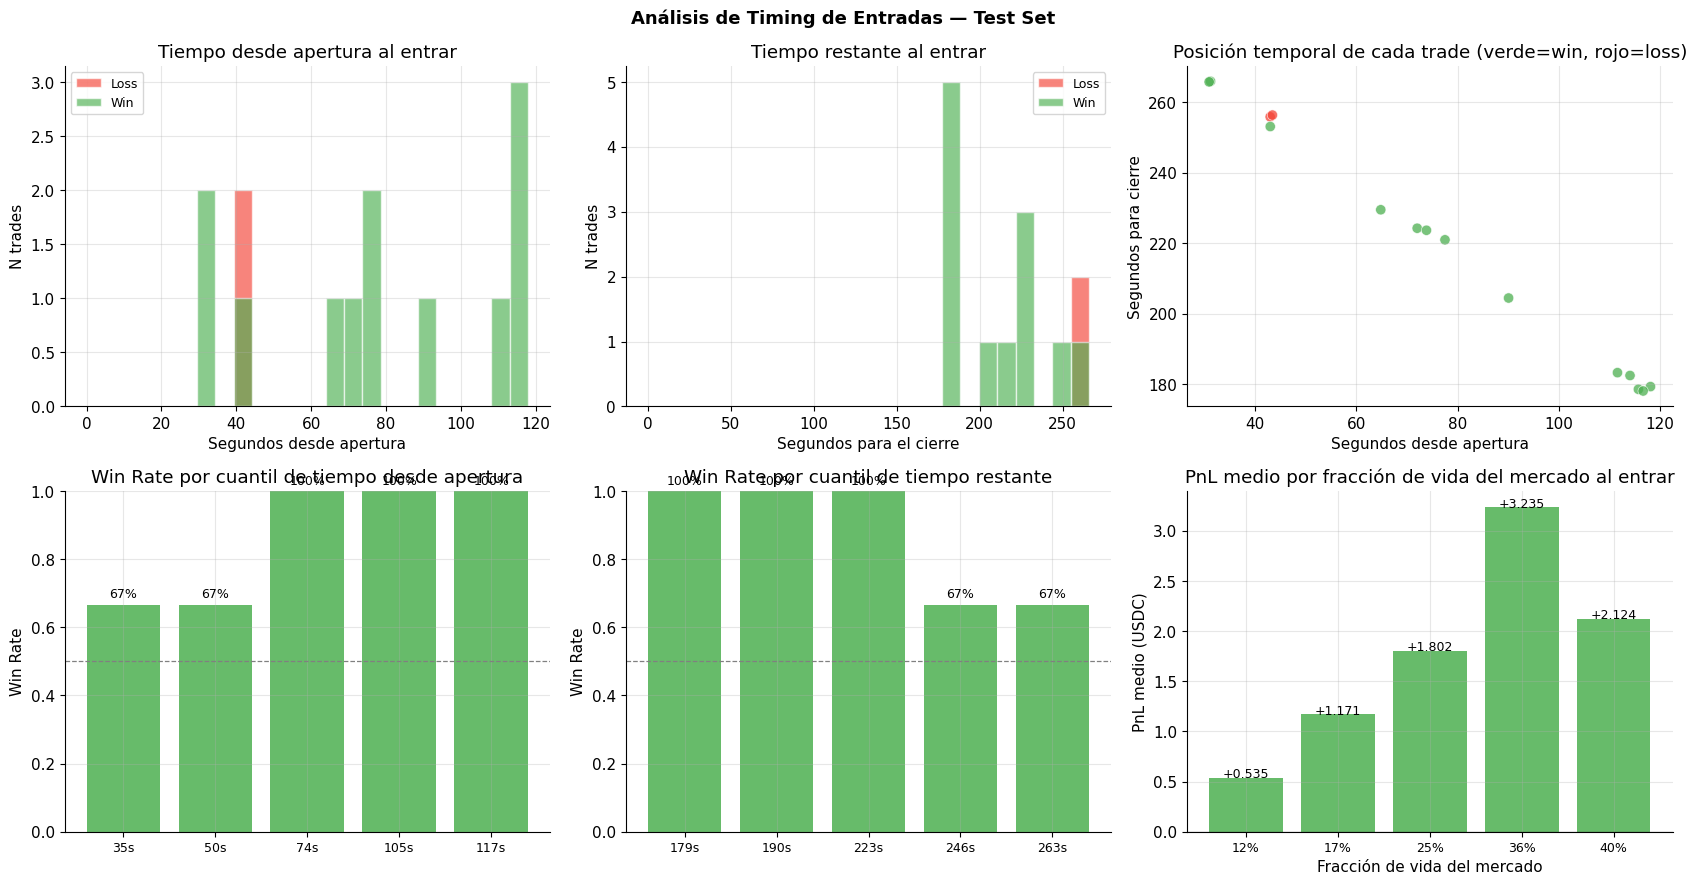


── Resumen de timing (test set) ──
  Tiempo medio de entrada : 76.4 s desde apertura
  Tiempo medio restante   : 220.1 s para cierre
  Duración media mercado  : 296.5 s
  Fracción media de vida  : 25.8%

       seconds_from_open  seconds_to_close  market_duration_s
count               15.0              15.0               15.0
mean                76.4             220.1              296.5
std                 33.1              34.0                1.7
min                 30.9             178.1              294.3
25%                 43.2             182.9              294.9
50%                 73.9             223.7              296.6
75%                112.8             254.5              297.5
max                118.1             266.0              299.8


In [93]:
# =============================================================================
# 9.5. ANÁLISIS DE TIMING DE TRADES
# =============================================================================
if not trade_log.empty and 'seconds_from_open' in trade_log.columns:
    has_timing = trade_log['seconds_from_open'].notna().any()
else:
    has_timing = False

if has_timing:
    tl = trade_log.dropna(subset=['seconds_from_open', 'seconds_to_close']).copy()
    tl['outcome'] = tl['pnl'].apply(lambda x: 'Win' if x > 0 else 'Loss')
    colors_wl = {'Win': '#4CAF50', 'Loss': '#F44336'}

    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    fig.suptitle('Análisis de Timing de Entradas — Test Set', fontsize=13, fontweight='bold')

    # ── A. Histograma: segundos desde apertura ───────────────────────────────
    ax = axes[0, 0]
    bins = np.linspace(0, tl['seconds_from_open'].quantile(0.99), 25)
    for outcome, grp in tl.groupby('outcome'):
        ax.hist(grp['seconds_from_open'], bins=bins, alpha=0.65,
                label=outcome, color=colors_wl[outcome], edgecolor='white')
    ax.set_title('Tiempo desde apertura al entrar')
    ax.set_xlabel('Segundos desde apertura'); ax.set_ylabel('N trades')
    ax.legend(fontsize=9)

    # ── B. Histograma: segundos para el cierre ───────────────────────────────
    ax = axes[0, 1]
    bins2 = np.linspace(0, tl['seconds_to_close'].quantile(0.99), 25)
    for outcome, grp in tl.groupby('outcome'):
        ax.hist(grp['seconds_to_close'], bins=bins2, alpha=0.65,
                label=outcome, color=colors_wl[outcome], edgecolor='white')
    ax.set_title('Tiempo restante al entrar')
    ax.set_xlabel('Segundos para el cierre'); ax.set_ylabel('N trades')
    ax.legend(fontsize=9)

    # ── C. Scatter: tiempo_desde_apertura vs tiempo_para_cierre, coloreado por PnL
    ax = axes[0, 2]
    c_arr = ['#4CAF50' if p > 0 else '#F44336' for p in tl['pnl']]
    sc = ax.scatter(tl['seconds_from_open'], tl['seconds_to_close'],
                    c=c_arr, alpha=0.75, s=55, edgecolors='white', lw=0.5)
    ax.set_title('Posición temporal de cada trade (verde=win, rojo=loss)')
    ax.set_xlabel('Segundos desde apertura')
    ax.set_ylabel('Segundos para cierre')

    # ── D. Win Rate vs cuantil de seconds_from_open ──────────────────────────
    ax = axes[1, 0]
    tl['_q_open'] = pd.qcut(tl['seconds_from_open'], q=5, labels=False, duplicates='drop')
    grp_open = tl.groupby('_q_open', observed=True)
    wr_open  = grp_open['pnl'].apply(lambda x: (x > 0).mean())
    mid_open = grp_open['seconds_from_open'].mean()
    bars = ax.bar(range(len(wr_open)), wr_open.values, alpha=0.85,
                  color=['#4CAF50' if v >= 0.5 else '#F44336' for v in wr_open.values])
    ax.axhline(0.5, ls='--', color='gray', lw=0.9)
    ax.set_xticks(range(len(wr_open)))
    ax.set_xticklabels([f'{v:.0f}s' for v in mid_open.values], fontsize=9)
    ax.set_title('Win Rate por cuantil de tiempo desde apertura')
    ax.set_ylabel('Win Rate'); ax.set_ylim(0, 1)
    for bar, v in zip(bars, wr_open.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.0%}', ha='center', fontsize=9)

    # ── E. Win Rate vs cuantil de seconds_to_close ───────────────────────────
    ax = axes[1, 1]
    tl['_q_close'] = pd.qcut(tl['seconds_to_close'], q=5, labels=False, duplicates='drop')
    grp_close = tl.groupby('_q_close', observed=True)
    wr_close  = grp_close['pnl'].apply(lambda x: (x > 0).mean())
    mid_close = grp_close['seconds_to_close'].mean()
    bars2 = ax.bar(range(len(wr_close)), wr_close.values, alpha=0.85,
                   color=['#4CAF50' if v >= 0.5 else '#F44336' for v in wr_close.values])
    ax.axhline(0.5, ls='--', color='gray', lw=0.9)
    ax.set_xticks(range(len(wr_close)))
    ax.set_xticklabels([f'{v:.0f}s' for v in mid_close.values], fontsize=9)
    ax.set_title('Win Rate por cuantil de tiempo restante')
    ax.set_ylabel('Win Rate'); ax.set_ylim(0, 1)
    for bar, v in zip(bars2, wr_close.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.0%}', ha='center', fontsize=9)

    # ── F. PnL medio vs franja temporal (segundos_desde_apertura / duración) ─
    ax = axes[1, 2]
    tl['entry_frac'] = tl['seconds_from_open'] / tl['market_duration_s'].clip(lower=1)
    tl['_q_frac'] = pd.qcut(tl['entry_frac'], q=5, labels=False, duplicates='drop')
    grp_frac = tl.groupby('_q_frac', observed=True)
    pnl_frac = grp_frac['pnl'].mean()
    mid_frac = grp_frac['entry_frac'].mean()
    bars3 = ax.bar(range(len(pnl_frac)), pnl_frac.values, alpha=0.85,
                   color=['#4CAF50' if v > 0 else '#F44336' for v in pnl_frac.values])
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(range(len(pnl_frac)))
    ax.set_xticklabels([f'{v:.0%}' for v in mid_frac.values], fontsize=9)
    ax.set_title('PnL medio por fracción de vida del mercado al entrar')
    ax.set_xlabel('Fracción de vida del mercado'); ax.set_ylabel('PnL medio (USDC)')
    for bar, v in zip(bars3, pnl_frac.values):
        ax.text(bar.get_x()+bar.get_width()/2, v + (0.003 if v >= 0 else -0.02),
                f'{v:+.3f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Tabla resumen de timing
    print("\n── Resumen de timing (test set) ──")
    print(f"  Tiempo medio de entrada : {tl['seconds_from_open'].mean():.1f} s desde apertura")
    print(f"  Tiempo medio restante   : {tl['seconds_to_close'].mean():.1f} s para cierre")
    print(f"  Duración media mercado  : {tl['market_duration_s'].mean():.1f} s")
    print(f"  Fracción media de vida  : {tl['entry_frac'].mean():.1%}")
    print()
    print(tl[['seconds_from_open','seconds_to_close','market_duration_s']].describe().round(1).to_string())
else:
    print("No hay columnas de timing en trade_log — asegúrate de haber ejecutado la Sección 2b.")



---
## 10 · Gráficos

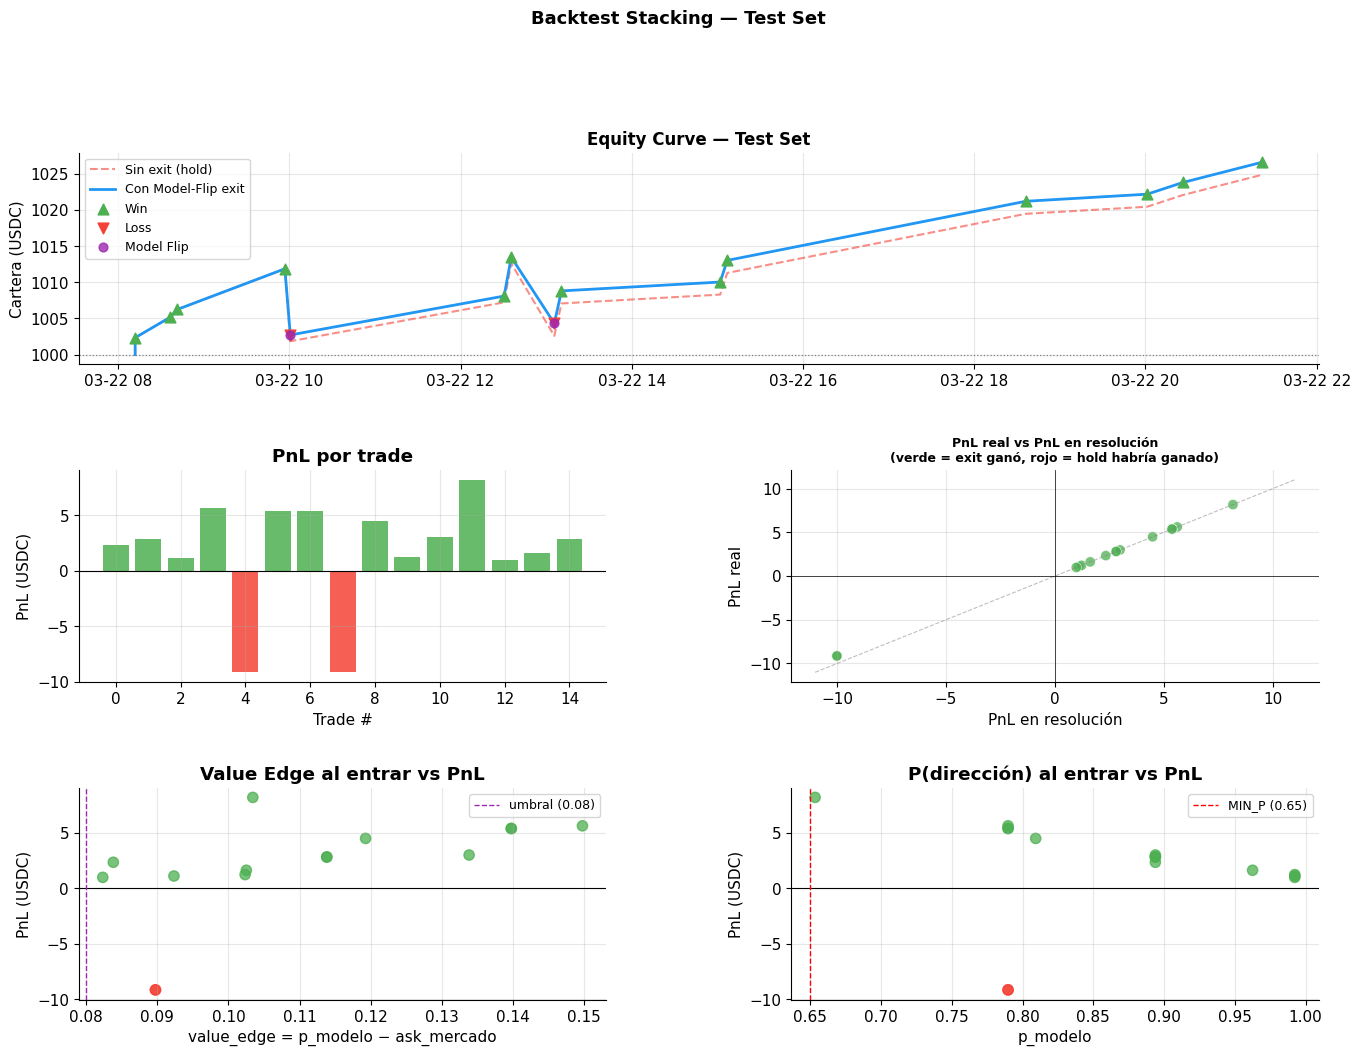

In [94]:
# =============================================================================
# 10. GRÁFICOS
# =============================================================================
if not trade_log.empty:
    fig = plt.figure(figsize=(16, 11))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)

    # ── 1. Equity curve ──────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, :])
    if not trade_log_no.empty:
        ax.plot(equity_no.index, equity_no.values,
                color='#F44336', lw=1.5, alpha=0.6, ls='--', label='Sin exit (hold)')
    ax.plot(equity.index, equity.values, color='#2196F3', lw=2.0, label='Con Model-Flip exit')
    ax.axhline(CFG['INIT_CAPITAL'], ls=':', color='gray', lw=0.9)

    wins_df  = trade_log[trade_log['pnl'] > 0]
    loses_df = trade_log[trade_log['pnl'] <= 0]
    flips_df = trade_log[trade_log['exit_type'] == 'MODEL_FLIP']

    ax.scatter(wins_df['timestamp'],  wins_df['equity'],
               marker='^', s=60, color='#4CAF50', zorder=5, label='Win')
    ax.scatter(loses_df['timestamp'], loses_df['equity'],
               marker='v', s=60, color='#F44336', zorder=5, label='Loss')
    ax.scatter(flips_df['timestamp'], flips_df['equity'],
               marker='o', s=40, color='#9C27B0', zorder=6, alpha=0.8, label='Model Flip')

    ax.set_title('Equity Curve — Test Set', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cartera (USDC)'); ax.legend(fontsize=9)

    # ── 2. PnL por trade ─────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    colors_bar = ['#4CAF50' if p > 0 else '#F44336' for p in trade_log['pnl']]
    ax.bar(range(len(trade_log)), trade_log['pnl'].values, color=colors_bar, alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title('PnL por trade', fontweight='bold')
    ax.set_xlabel('Trade #'); ax.set_ylabel('PnL (USDC)')

    # ── 3. Exit: PnL con exit vs PnL en resolución ───────────────────────────
    ax = fig.add_subplot(gs[1, 1])
    c_arr = ['#4CAF50' if p >= r else '#F44336'
             for p, r in zip(trade_log['pnl'], trade_log['pnl_at_resolution'])]
    ax.scatter(trade_log['pnl_at_resolution'], trade_log['pnl'],
               c=c_arr, alpha=0.75, s=55, edgecolors='white', lw=0.5)
    lim = max(abs(trade_log[['pnl','pnl_at_resolution']].values).max() * 1.1, 1)
    ax.plot([-lim, lim], [-lim, lim], '--', color='gray', alpha=0.5, lw=0.8)
    ax.axhline(0, color='black', lw=0.5); ax.axvline(0, color='black', lw=0.5)
    ax.set_title('PnL real vs PnL en resolución\n(verde = exit ganó, rojo = hold habría ganado)',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('PnL en resolución'); ax.set_ylabel('PnL real')

    # ── 4. VALUE_EDGE de entrada vs PnL ──────────────────────────────────────
    ax = fig.add_subplot(gs[2, 0])
    c_arr2 = ['#4CAF50' if p > 0 else '#F44336' for p in trade_log['pnl']]
    ax.scatter(trade_log['value_edge_entry'], trade_log['pnl'],
               c=c_arr2, alpha=0.75, s=55)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(CFG['VALUE_EDGE'], ls='--', color='#9C27B0', lw=1, label=f"umbral ({CFG['VALUE_EDGE']})")
    ax.set_title('Value Edge al entrar vs PnL', fontweight='bold')
    ax.set_xlabel('value_edge = p_modelo − ask_mercado'); ax.set_ylabel('PnL (USDC)')
    ax.legend(fontsize=9)

    # ── 5. P(dirección) vs PnL ───────────────────────────────────────────────
    ax = fig.add_subplot(gs[2, 1])
    ax.scatter(trade_log['p_entry'], trade_log['pnl'], c=c_arr2, alpha=0.75, s=55)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(CFG['MIN_P'], ls='--', color='red', lw=1, label=f"MIN_P ({CFG['MIN_P']})")
    ax.set_title('P(dirección) al entrar vs PnL', fontweight='bold')
    ax.set_xlabel('p_modelo'); ax.set_ylabel('PnL (USDC)')
    ax.legend(fontsize=9)

    plt.suptitle('Backtest Stacking — Test Set', fontsize=13, fontweight='bold', y=1.01)
    plt.show()

---
## 11 · Sensibilidad de Parámetros

In [ ]:
# =============================================================================
# 11. SENSIBILIDAD: VALUE_EDGE × MIN_P × FLIP_THRESH
# =============================================================================
ve_grid     = [0.03, 0.05, 0.08, 0.10, 0.13]
mp_grid     = [0.60, 0.63, 0.65, 0.68, 0.70]
flip_grid   = [0.25, 0.30, 0.35]

sens_rows = []
for ve in ve_grid:
    for mp in mp_grid:
        for flip in flip_grid:
            cfg_s = {**CFG, 'VALUE_EDGE': ve, 'MIN_P': mp, 'FLIP_THRESH': flip}
            tl, eq_s = run_backtest(test_fe, cfg_s)
            if tl.empty:
                sens_rows.append({'VE': ve, 'MIN_P': mp, 'Flip': flip,
                                  'N': 0, 'WR': np.nan, 'PnL': np.nan, 'PF': np.nan})
                continue
            gp = tl[tl['pnl'] > 0]['pnl'].sum()
            gl = tl[tl['pnl'] < 0]['pnl'].abs().sum()
            sens_rows.append({
                'VE'   : ve, 'MIN_P': mp, 'Flip': flip,
                'N'    : len(tl),
                'WR'   : round((tl['pnl']>0).mean(), 3),
                'PnL'  : round(tl['pnl'].sum(),       2),
                'PF'   : round(gp / (gl + 1e-9),       3),
            })

df_sens = pd.DataFrame(sens_rows)
print("Resultados del barrido de parámetros (test set):")
print(df_sens.sort_values('PnL', ascending=False).to_string(index=False))

best_row = df_sens.loc[df_sens['PnL'].idxmax()]
print(f"\nMejor combinación (PnL):  VE={best_row.VE}  MIN_P={best_row.MIN_P}  Flip={best_row.Flip}")
print(f"  N={best_row.N}  WR={best_row.WR:.1%}  PnL={best_row.PnL:+.2f}  PF={best_row.PF:.3f}")

best_flip = df_sens.loc[df_sens['PnL'].idxmax(), 'Flip']
sub = df_sens[df_sens['Flip'] == best_flip]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title, cmap in [
    (axes[0], 'PnL', f'PnL (USDC) — Flip={best_flip}', 'RdYlGn'),
    (axes[1], 'WR',  f'Win Rate — Flip={best_flip}',    'RdYlGn'),
]:
    pivot = sub.pivot(index='MIN_P', columns='VE', values=col)
    im = ax.imshow(pivot.values.astype(float), cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    ax.set_xlabel('VALUE_EDGE'); ax.set_ylabel('MIN_P')
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(float(v)):
                ax.text(j, i, f'{float(v):.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()


---
## 13 · Resumen y Guía de Ajuste

In [ ]:
# =============================================================================
# 13. RESUMEN FINAL
# =============================================================================
D = '=' * 58
print(D)
print('  RESUMEN — Polymarket BTC XGBoost v8')
print(D)
print(f"  Modelo      : {'XGBoost' if USE_XGB else 'HistGBT (sklearn)'}")
print(f"  Features    : {len(FEATURES)}")
print(f"  Test AUC    : {roc_auc_score(y_te, MODEL.predict_proba(X_te)[:,1]):.4f}")
print(f"  Filtros     : MIN_P>={CFG['MIN_P']}  VALUE_EDGE>={CFG['VALUE_EDGE']}")
print(f"  Ventana     : progress ∈ [{CFG['ENTRY_LO']}, {CFG['ENTRY_HI']}]")
print(f"  Exit        : Model-Flip < {CFG['FLIP_THRESH']} (sin stop-loss por precio)")

if not trade_log.empty and not trade_log_no.empty:
    print(f"\n  {'':18} {'CON exit':>12} {'SIN exit':>12}")
    print(f"  {'-'*44}")
    print(f"  {'N trades':<18} {len(trade_log):>12} {len(trade_log_no):>12}")
    print(f"  {'Win Rate':<18} {(trade_log['pnl']>0).mean():>11.1%} {(trade_log_no['pnl']>0).mean():>11.1%}")
    print(f"  {'PnL Total':<18} {trade_log['pnl'].sum():>+11.2f} {trade_log_no['pnl'].sum():>+11.2f}")
    eq=equity.values; rm=np.maximum.accumulate(eq); mdd=((eq-rm)/rm).min()
    eq2=equity_no.values; rm2=np.maximum.accumulate(eq2); mdd2=((eq2-rm2)/rm2).min()
    print(f"  {'Max Drawdown':<18} {mdd:>11.2%} {mdd2:>11.2%}")
print(D)

print("""
GUÍA DE AJUSTE DE PARÁMETROS:

  VALUE_EDGE  (más importante):
    • 0.03 — más trades, WR moderada
    • 0.05 — balance óptimo
    • 0.08+ — menos trades, WR más alta, menor diversificación

  MIN_P:
    • 0.60 — incluye señales moderadas del modelo
    • 0.65 — balance entre cantidad y calidad
    • 0.70 — solo señales de alta convicción

  FLIP_THRESH:
    • 0.10 — exit solo en casos extremos de cambio de señal
    • 0.15 — balance (configuración actual)
    • 0.25 — más agresivo, sale antes ante incertidumbre

  ENTRY_LO / ENTRY_HI:
    Controlan en qué fase del mercado se permite entrar (como fracción
    de su duración). Evita price-discovery inicial y convergencia final.
""")


  RESUMEN — Polymarket BTC XGBoost v8
  Modelo      : XGBoost
  Features    : 16
  Test AUC    : 0.8432
  Filtros     : MIN_P>=0.7  VALUE_EDGE>=0.08
  Ventana     : progress ∈ [0.1, 0.5]
  Exit        : Model-Flip < 0.2 (sin stop-loss por precio)

                         CON exit     SIN exit
  --------------------------------------------
  N trades                     23           23
  Win Rate                 78.3%       78.3%
  PnL Total                +1.00       -3.46
  Max Drawdown            -2.09%      -2.45%

GUÍA DE AJUSTE DE PARÁMETROS:

  VALUE_EDGE  (más importante):
    • 0.03 — más trades, WR moderada
    • 0.05 — balance óptimo
    • 0.08+ — menos trades, WR más alta, menor diversificación

  MIN_P:
    • 0.60 — incluye señales moderadas del modelo
    • 0.65 — balance entre cantidad y calidad
    • 0.70 — solo señales de alta convicción

  FLIP_THRESH:
    • 0.10 — exit solo en casos extremos de cambio de señal
    • 0.15 — balance (configuración actual)
    • 0.25 — 